In [55]:
import time

def timer(func):
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        print("Time:", time.time() - start)
        return result
    return wrapper

In [56]:
# Our standard imports for maths and basic methodology
import numpy as np
from sklearn.model_selection import train_test_split

# For user feedback
from tqdm import tqdm
import matplotlib.pyplot as plt

# Imports for pytorch
import torch
import torch.nn as nn

Let's see if we have a GPU.

In [57]:
if torch.cuda.is_available():
  print("CUDA GPUs:")
  for i in range(torch.cuda.device_count()):
    device_name = torch.cuda.get_device_name(i)
    print(f"  {device_name}")
elif hasattr(torch, 'xpu') and torch.xpu.is_available():
  print("Intel XPU (Arc/Battlemage) GPUs:")
  for i in range(torch.xpu.device_count()):
    print(f"  {torch.xpu.get_device_name(i)}")
elif torch.backends.mps.is_available():
  print("MPS (Metal Performance Shaders) GPU available")
  print("  Apple Silicon or Intel integrated GPU")
else:
  print("No GPU available")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

No GPU available


In [58]:
# Check PyTorch version and XPU support
print(f"PyTorch version: {torch.__version__}")
print(f"Has 'xpu' attribute: {hasattr(torch, 'xpu')}")
if hasattr(torch, 'xpu'):
    print(f"XPU available: {torch.xpu.is_available()}")
    if torch.xpu.is_available():
        print(f"XPU device count: {torch.xpu.device_count()}")


PyTorch version: 2.12.0a0+git9e551d2
Has 'xpu' attribute: True
XPU available: False


## Load tagging data

Vi vill ha listor X och y, med en lista för varje mening, e.g. \
`[['The', 'Fulton', ...], [...], ...]` \
`[['DET', 'NOUN', ...], [...], ...]`

In [59]:
from pathlib import Path
import subprocess

ROOT = Path.cwd()

def my_little_download_helper(repo, use_xpos=False, verbose=False):
    name = repo.split(".")[-2].split("/")[-1]
    if verbose:
        print(name)
    download_dir = ROOT / name

    if not Path.exists(download_dir):
        try:
            result = subprocess.run(
                ["git", "clone", repo, download_dir],
            )
        except CalledProcessError:
            print("Perhaps you don't have git installed?")

    files = sorted(list(Path(download_dir).rglob("*.conllu")))
    for file in files:
        with open(file, "r", encoding="utf-8") as f:
            lines = f.read().split("sent_id ")                      # plockar ut meningars conllu-avsnitt
            filename = str(file).split(".")[0]
            #if filename.endswith("dev"):
            #    dev = lines
            if filename.endswith("test"):
                test = lines
            elif filename.endswith("train"):
                train = lines
    if verbose:
        #print(f"Dev {name}: {dev[:4]}")
        print(f"\tTest {name}: {test[:4]}")
        print(f"\tTrain {name}: {train[:4]}")

    # med meningarna grovt uppdelade ordnar vi till list-formaten vi vill ha
    X_train = []
    y_train = []
    for s in train[1:]:                                        # exkludera filnamnet
        word_rows = s.split("\n")
        word_rows = [l for l in word_rows if l and l[0].isdigit()]  # första fältet är index
        sentence_X = []
        sentence_y = []
        for row in word_rows:
            columns = row.split("\t")
            assert len(columns) == 10, "Conllu misformatted!"       # conllu ska ha 10 fält; tomma fält har "_"
            word_token = columns[1]
            pos = columns[3]
            if use_xpos and columns[4] != "_":                      # om xpos finns och inte är tomt, använd det för "xpos/pos"-experimentet
                pos = columns[4]
            sentence_X.append(word_token)
            sentence_y.append(pos)
        X_train.append(sentence_X)
        y_train.append(sentence_y)
    
    X_test = []
    y_test = []
    for s in test[1:]:
        word_rows = s.split("\n")
        word_rows = [l for l in word_rows if l and l[0].isdigit()]
        sentence_X = []
        sentence_y = []
        for row in word_rows:
            columns = row.split("\t")
            assert len(columns) == 10, "Conllu misformatted!"
            word_token = columns[1]
            pos = columns[3]
            if use_xpos and columns[4] != "_":
                pos = columns[4]
            sentence_X.append(word_token)
            sentence_y.append(pos)
        X_test.append(sentence_X)
        y_test.append(sentence_y)

    assert len(X_train) == len(y_train), "Not same amount of features as responses!"
    assert len(X_test) == len(y_test), "Not same amount of features as responses!"

    return X_train, y_train, X_test, y_test, name


repos = {
    "https://github.com/UniversalDependencies/UD_Thai-TUD.git": ["news"],
    "https://github.com/UniversalDependencies/UD_Ancient_Greek-PTNK.git": ["religion"],
    "https://github.com/UniversalDependencies/UD_Ancient_Greek-PROIEL.git": ["religion", "history"],
    "https://github.com/UniversalDependencies/UD_Ancient_Greek-Perseus.git": ["fiction"],
    "https://github.com/UniversalDependencies/UD_Latin-UDante.git": ["nonfiction", "poetry", "email"],
    "https://github.com/UniversalDependencies/UD_Latin-ITTB.git": ["nonfiction"],
    "https://github.com/UniversalDependencies/UD_Latin-LLCT.git": ["nonfiction", "legal"],
    "https://github.com/UniversalDependencies/UD_Latin-CIRCSE.git": ["fiction", "poetry"],
    "https://github.com/UniversalDependencies/UD_Latin-Perseus.git": ["fiction", "nonfiction", "religion"],
    "https://github.com/UniversalDependencies/UD_Latin-PROIEL.git": ["religion", "nonfiction"],
}

all_Xs_and_ys = {}
for repo in repos:
    X_train, y_train, X_test, y_test, name = my_little_download_helper(repo, use_xpos=False, verbose=True)
    all_Xs_and_ys[name] = (X_train, y_train, X_test, y_test)

all_Xs_and_ys_xpos = {}
for repo in repos:
    X_train, y_train, X_test, y_test, name = my_little_download_helper(repo, use_xpos=True, verbose=False)
    all_Xs_and_ys_xpos[name] = (X_train, y_train, X_test, y_test)

UD_Thai-TUD
	Test UD_Thai-TUD: ['# filename = tnc_NWRP_EN016\n# ', '= 1857\n# text = ยุ้ยจะบอกว่ามันนานแล้ว แต่เรารักกัน\n1\tยุ้ย\t_\tPROPN\t_\t_\t3\tnsubj\t_\tSpaceAfter=No\n2\tจะ\t_\tAUX\t_\t_\t3\taux\t_\tSpaceAfter=No\n3\tบอก\t_\tVERB\t_\t_\t0\troot\t_\tSpaceAfter=No\n4\tว่า\t_\tSCONJ\t_\t_\t6\tmark\t_\tSpaceAfter=No\n5\tมัน\t_\tPRON\t_\t_\t6\texpl\t_\tSpaceAfter=No\n6\tนาน\t_\tVERB\t_\t_\t3\tccomp\t_\tSpaceAfter=No\n7\tแล้ว\t_\tAUX\t_\t_\t6\taux\t_\t_\n8\tแต่\t_\tCCONJ\t_\t_\t10\tcc\t_\tSpaceAfter=No\n9\tเรา\t_\tPRON\t_\t_\t10\tnsubj\t_\tSpaceAfter=No\n10\tรัก\t_\tVERB\t_\t_\t6\tconj\t_\tSpaceAfter=No\n11\tกัน\t_\tPRON\t_\t_\t10\tobl\t_\tSpaceAfter=No\n\n# filename = tnc_ESUN298\n# ', '= 1780\n# text = ความรักเป็นสิ่งที่สวยงาม แต่แน่นอนว่ามันย่อมให้ทั้งความสุขและความทุกข์ ขึ้นอยู่กับว่าคุณจะมองมันอย่างไร\n1\tความ\t_\tNOUN\t_\t_\t4\tnsubj\t_\tSpaceAfter=No\n2\tรัก\t_\tVERB\t_\t_\t1\tacl\t_\tSpaceAfter=No\n3\tเป็น\t_\tAUX\t_\t_\t4\tcop\t_\tSpaceAfter=No\n4\tสิ่ง\t_\tNOUN\t_\t_\t0\tro

En liten slumpmässig sanity-check:

[['liber', 'generationis', 'Iesu', 'Christi', 'filii', 'David', 'filii', 'Abraham'], ['Abraham', 'genuit', 'Isaac'], ['Isaac', 'autem', 'genuit', 'Iacob'], ['Iacob', 'autem', 'genuit', 'Iudam', 'et', 'fratres', 'eius'], ['Iudas', 'autem', 'genuit', 'Phares', 'et', 'Zara', 'de', 'Thamar'], ['Phares', 'autem', 'genuit', 'Esrom'], ['Esrom', 'autem', 'genuit', 'Aram'], ['Aram', 'autem', 'genuit', 'Aminadab'], ['Aminadab', 'autem', 'genuit', 'Naasson'], ['Naasson', 'autem', 'genuit', 'Salmon'], ['Salmon', 'autem', 'genuit', 'Booz', 'de', 'Rachab'], ['Booz', 'autem', 'genuit', 'Obed', 'ex', 'Ruth'], ['Obed', 'autem', 'genuit', 'Iesse'], ['Iesse', 'autem', 'genuit', 'David', 'regem'], ['David', 'autem', 'rex', 'genuit', 'Salomonem', 'ex', 'ea', 'quae', 'fuit', 'Uriae'], ['Salomon', 'autem', 'genuit', 'Roboam'], ['Roboam', 'autem', 'genuit', 'Abiam'], ['Abia', 'autem', 'genuit', 'Asa'], ['Asa', 'autem', 'genuit', 'Iosaphat'], ['Iosaphat', 'autem', 'genuit', 'Ioram'], ['Ioram', 'autem', 'genuit

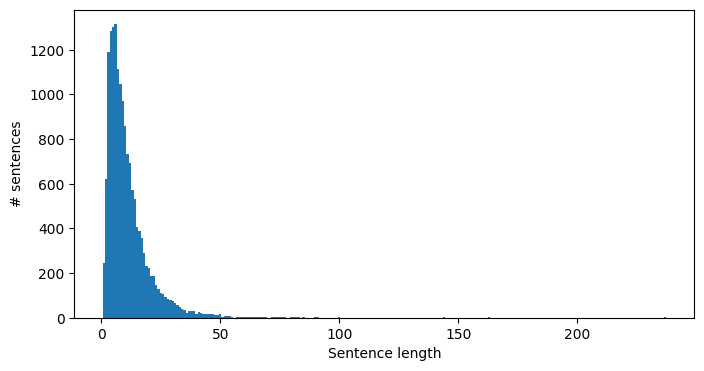

In [60]:
import numpy as np

sample = np.random.choice(list(all_Xs_and_ys.keys()))
quick_check = all_Xs_and_ys[sample]

print(quick_check[0])
print(quick_check[1])

print("The training set includes %i sentences" % len(quick_check[0]))
print("The test set includes %i sentences" % len(quick_check[1]))

l = np.asarray([len(x) for x in quick_check[0]], dtype=int)
plt.figure(figsize=(8, 4))
x = np.unique(l)
plt.bar(x, [np.sum(l==e) for e in x], width=1)
plt.xlabel("Sentence length")
plt.ylabel("# sentences")
plt.show()

## Data encoding and padding

Mitt experiment för att hantera OOV är att implementera GPT2's BPE. 
Jag kommer att låta varje ord *representeras av sin första token* enbart, eftersom vår modell *förväntar sig ett heltal per ord* och inget mer. 
Jag testar att köra den förtränade vokabulären som kommer från websidor som länkats mer än 3 gånger på Reddit när det begav sig.
Det betyder att det garanterat finns både thailändska och grekiska eftersom alla språk har i all fall någon subreddit, även om det inte är mycket att hänga i jul-GPT2n, så att säga. HF hostar originalfilerna. 

HF har gjort en refactor av originalkoden i Rust och inkluderat den i transformers. 
Jag försöke först med PyTorchs version i torchtext, men den är legacy och fungerade inte längre tillsammans med modern torch.

Outputen ser konstig ut för icke-latinska alfabet eftersom denna BPE har lärt sig förhållandevis få merges för dessa. 
Detta gör inte så mycket eftersom när man decodar på slutet så får man ut fina unicode-bokstäver igen, oavsett alfabet.

In [61]:
from transformers import GPT2TokenizerFast

bpe_tokenizer = GPT2TokenizerFast.from_pretrained("gpt2", local_files_only=True)

# Hur tokeniseras "Hello world" av GPT2s BPE på mina tre språk?
print(bpe_tokenizer.tokenize("Ave o munde!"))       # latin
print(bpe_tokenizer.tokenize("χαῖρε ὦ κόσμε"))      # antik grekiska
print(bpe_tokenizer.tokenize("สวัสดีชาวโลก"))         # thailändska

thai_sentence = "สวัสดีชาวโลก"
assert bpe_tokenizer.decode(bpe_tokenizer.encode(thai_sentence)) == thai_sentence, "Encoding and decoding should be consistent!"

def tokenize(X, y, use_bpe=False, verbose=True):

    if use_bpe:
        token2idx = bpe_tokenizer.get_vocab()

        # add special tokens if missing
        if "<PAD>" not in token2idx:
            token2idx["<PAD>"] = len(token2idx)
        if "<UNK>" not in token2idx:
            token2idx["<UNK>"] = len(token2idx)

    else:
        tokens = {token for sentence in X for token in sentence}
        idx2token = list(tokens)
        idx2token.insert(0, '<UNK>')
        idx2token.append('<PAD>')
        token2idx = {token: idx for idx, token in enumerate(idx2token)}

    # tags unchanged
    tags = {tag for tags in y for tag in tags}
    tags.discard('X')

    idx2tag = list(tags)
    idx2tag.insert(0, 'X')
    idx2tag.append('<PAD>')

    tag2idx = {tag: idx for idx, tag in enumerate(idx2tag)}

    if verbose:
        if use_bpe:
            print("\tUsing GPT-2 BPE vocab:", len(token2idx))
        else:
            print("\tCustom vocab:", len(token2idx))
        print("\t", idx2tag)

    return token2idx, tag2idx

def encode_sentence(sentence, token2idx, use_bpe=False):

    if use_bpe:
        ids = []
        for word in sentence:
            sub = bpe_tokenizer.encode(" " + word, add_special_tokens=False)    # vi hjälper BPE-tokenizern att hitta ordgränser genom att lägga till ett mellanslag i början av varje ord
            if len(sub) == 0:
                ids.append(token2idx["<UNK>"])
            else:
                ids.append(sub[0])                                              # använd bara första subtokens id för varje ord, för bibehålla modellarkitekturen för experimentet
        return ids

    else:
        return [token2idx.get(w, token2idx['<UNK>']) for w in sentence]

['A', 've', 'Ġo', 'Ġmund', 'e', '!']
['Ï', 'ĩ', 'Î±', 'á', '¿', 'ĸ', 'Ïģ', 'Îµ', 'Ġá', '½', '¦', 'ĠÎ', 'º', 'Ï', 'Į', 'Ïĥ', 'Î¼', 'Îµ']
['à¸', 'ª', 'à¸', '§', 'à¸', '±', 'à¸', 'ª', 'à¸', 'Ķ', 'à¸', 'µ', 'à¸', 'Ĭ', 'à¸', '²', 'à¸', '§', 'à¹', 'Ĥ', 'à¸', '¥', 'à¸', 'ģ']


In [71]:
def pad_and_encode(batch, token2idx, tag2idx, use_bpe=False):

  sentences, labels = zip(*batch)

  assert len(sentences) == len(labels)
  assert np.all([len(sentence) == len(tags) for sentence, tags in zip(sentences, labels)])

  max_sentence_length = max(len(sentence) for sentence in sentences)

  padded_sentences = torch.full(
      (len(sentences), max_sentence_length),
      token2idx['<PAD>'],
      dtype=torch.long
  )

  padded_labels = torch.full(
      (len(sentences), max_sentence_length),
      tag2idx['<PAD>'],
      dtype=torch.long
  )

  for i, (sentence, tags) in enumerate(zip(sentences, labels)):

      encoded = encode_sentence(sentence, token2idx, use_bpe)

      padded_sentences[i, :len(encoded)] = torch.tensor(encoded)

      padded_labels[i, :len(tags)] = torch.tensor(
          [tag2idx.get(tag, tag2idx['X']) for tag in tags]          # om tag inte finns i tag2idx, använd 'X' som default för att hantera eventuella okända taggar i testdata (de finns!!)
      )

  return padded_sentences, padded_labels

In [63]:
from torch.utils.data import Dataset, DataLoader

def rand_letter_noise(x):
    alfabeten = "abcdefghijklmnopqrstuvwxyz αβγδεζηθκλμνξοπρσςτυφχψω กขฃคฅฆงจฉชซฌญฎฏฐฑฒณดตถทธนบปผ"

    word_idx = torch.randint(0, len(x), (1,)).item()                 # .item() gör 0-dim tensorer till ints
    word = x[word_idx]
    rand_idx = torch.randint(0, len(word), (1,)).item()
    rand_letter = torch.randint(0, len(alfabeten), (1,)).item()

    noisy_word = word[:rand_idx] + alfabeten[rand_letter] + word[rand_idx+1:]

    x_hat = x.copy()                                                 # för att inte ändra originalet
    x_hat[word_idx] = noisy_word

    return x_hat

class UDDataset(Dataset):
    """UD dataset."""

    def __init__(self, X, y, transform=rand_letter_noise):
        """
        Arguments:
            X (list): List of token sequences (lists)
            y (list): List of tag sequences (lists)
        """
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        x = self.X[idx]             # x is list of the words in a sentence
        y = self.y[idx]

        if self.transform:
            x = self.transform(x)

        return x, y

Jag ger min dataloader extremt overkill prestanda för att det är roligt.

In [64]:
import os
import multiprocessing as mp
from functools import partial
mp.set_start_method("fork", force=True)                                # från äldre python för linux fork subprocesser

# glob settings
cores = os.cpu_count()
batch_size = 256

def dataloader_loader(dataset, token2idx, tag2idx, use_bpe=False):     # Define the size of each batch
  cats = DataLoader(dataset,                                           # https://platform.theverge.com/wp-content/uploads/sites/2/chorus/uploads/chorus_asset/file/23666725/SEGA_Genesis___June_2022_Game_Updates___Nintendo_Switch_Online_0_29_screenshot.png?quality=90&strip=all&crop=0,1.6437308868502,100,96.7125382263
                    batch_size=batch_size,                             
                    shuffle=False, 
                    num_workers=cores,                                 # All your CPU cores are belong to us. HA HA HA HA...
                    persistent_workers=False,
                    collate_fn=partial(pad_and_encode,                 # bind token2idx och tag2idx till pad_and_encode
                                       token2idx=token2idx,
                                       tag2idx=tag2idx,
                                       use_bpe=use_bpe)
  )
  return cats

print("Take off every 'Zig!")

Take off every 'Zig!


## Model

In [ ]:
class LSTMTagger(nn.Module):
  def __init__(self, word_embedding_dim, lstm_hidden_dim, vocabulary_size, tagset_size, token2idx, dropout=0.0, bidirectional=False, use_gru=False, layers=1):
    """An LSTM based tagger

    word_embedding_dim
      The dimensionality of the word embedding
    lstm_hidden_dim
      The dimensionality of the hidden state in the LSTM
    vocabulary_size
      The number of unique tokens in the word embedding (including <PAD> etc)
    tagset_size
      The number of unique POS tags (not including <PAD>, as we don't want to predict it)
    """
    super(LSTMTagger, self).__init__()                                          # We need to initialise the class we are inheriting from
    self.lstm_hidden_dim_ = lstm_hidden_dim                                     # This simply stores the parameters
    self.gru_hidden_dim_ = lstm_hidden_dim
    if bidirectional:
      self.gru_hidden_dim_ = lstm_hidden_dim*2
    self.vocabulary_size_ = vocabulary_size
    self.tagset_size_ = tagset_size
    self.token2idx = token2idx
    self.use_gru = use_gru

    self._word_embedding = nn.Embedding(num_embeddings=vocabulary_size,         # Creates the vector space for the input words
                                        embedding_dim=word_embedding_dim,
                                        padding_idx=token2idx['<PAD>'])
    self._lstm = nn.LSTM(input_size=word_embedding_dim,                         # The LSTM takes an embedded sentence as input, and outputs
                         hidden_size=lstm_hidden_dim,                           # vectors with dimensionality lstm_hidden_dim.
                         batch_first=True,
                         num_layers=layers, 
                         bidirectional=bidirectional)                           # output: (N, L, D*H) = (batch_size, sequence_length, D*hidden_size) where D is 2 if bidirectional=True, else 1
                                                                                # source: https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html
    self._gru = nn.GRU(input_size=self.gru_hidden_dim_,                
                       hidden_size=lstm_hidden_dim,                           
                       batch_first=True,
                       num_layers=layers,
                       bidirectional=bidirectional)
    self._fc = nn.Linear(self.gru_hidden_dim_, tagset_size)
    self._dropout = nn.Dropout(dropout)
    self._softmax = nn.LogSoftmax(dim=1)                                        # Softmax of outputting PDFs over tags

    self.training_loss_ = list()                                                # For plotting
    self.training_accuracy_ = list()

  def forward(self, padded_sentences):
    """The forward pass through the network"""
    batch_size, max_sentence_length = padded_sentences.size()

    embedded_sentences = self._word_embedding(padded_sentences)                 # Sentences encoded as integers are mapped to vectors

    sentence_lengths = (padded_sentences!=self.token2idx['<PAD>']).sum(dim=1)   # Find the length of sentences
    sentence_lengths = sentence_lengths.long().cpu()                            # Ensure the correct format
    
    X = embedded_sentences

    # layers
    X = self._dropout(X)                                                         # dropout vill inte ha packed
    X = nn.utils.rnn.pack_padded_sequence(X, sentence_lengths,                   # Packa innan LSTM
                                          batch_first=True, enforce_sorted=False)
    X, _ = self._lstm(X)                                                        # Run the LSTM layer
    if self.use_gru == True:
      X, _ = self._gru(X)                                                       # Run the GRU before the LSTM layer  
    X, _ = nn.utils.rnn.pad_packed_sequence(X, batch_first=True)                # Vi slänger hidden layer för att vi är inte intresserade av sentence embeddings1
    X = X.contiguous().view(-1, X.shape[2])                                     # .shape[2] because the hidden state is the third dim of the LSTM output
    tag_space = self._fc(X)                                                     # Fully connected layer
    tag_scores = self._softmax(tag_space)                                       # Softmax is applied to normalise the outputs
    return tag_scores.view(batch_size, max_sentence_length, self.tagset_size_)

## Network training

### Träningsscriptet

Här tränas de tio modellerna. 

In [77]:
@timer
def initialize_singularity(epochs = 5, test_mode = False, dropout=0.0, bidirectional=False, use_gru=False, use_noise=False, use_bpe=False, use_xpos=False, layers=1, verbose=True):
  models = {}
  avg_loss_dict = {}
  avg_acc_dict = {}
  for name in tqdm(all_Xs_and_ys.keys(), unit="UD treebank", disable=not verbose):
    if verbose:
      print(name)
    X_train, y_train, X_test, y_test = all_Xs_and_ys[name]
    if use_xpos:
      X_train, y_train, X_test, y_test = all_Xs_and_ys_xpos[name]

    X = X_train
    y = y_train

    if test_mode:
      X = X_test
      y = y_test
    
    token2idx, tag2idx = tokenize(X, y, use_bpe=use_bpe, verbose=verbose)

    model = LSTMTagger(word_embedding_dim=32,                                        # Dimensionality of the work embedding
                       lstm_hidden_dim=64,                                           # Dimensionality of the hidden state in the LSTM
                       vocabulary_size=len(token2idx),                               # The vocabulary incudes both the 'padding' and 'unknown' symbols
                       tagset_size=len(tag2idx)-1,                                   # We have no interest in the network outputting the padding symbol
                       token2idx=token2idx,
                       dropout=dropout,                                              # Regularization
                       bidirectional=bidirectional,
                       use_gru=use_gru,
                       layers=layers
    )

    if torch.cuda.is_available():
      model.to(device)
    
    loss_function = nn.NLLLoss(ignore_index=tag2idx['<PAD>'])                       # NLLLoss = Negative Log Likelihood Loss.
                                                                                    # The loss function will ignore the padding index in the targets.
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)                       # We give the optimiser the parameters to work with, note that we can choose to only give some parameters
    
    dataset = UDDataset(X, y, transform=rand_letter_noise if use_noise else None)
    dataloader = dataloader_loader(dataset, token2idx, tag2idx, use_bpe=use_bpe)                     # The DataLoader is directly iterable 
    for epoch in range(epochs):                                                     # Times to loop over the full dataset
        for inputs, targets in tqdm(
          dataloader,
          unit="batch",
          desc=f"\tEpoch {epoch}",
          disable=not verbose
        ):                                                                          # Loop once over the training data
          
          optimizer.zero_grad()                                                     # Reset only the gradients that were actually updated
          scores = model(inputs)                                                    # Forward pass
          loss = loss_function(scores.view(-1, model.tagset_size_),                 # Get loss, the data is reshaped as a long line of predictions and targets
                              targets.view(-1))
          loss.backward()                                                           # Backpropagate the error
          optimizer.step()                                                          # Run the optimizer to change the weights w.r.t the loss
          predictions = scores.argmax(dim=2, keepdim=True).squeeze()                # Calculate the batch training accuracy
          mask = targets!=tag2idx['<PAD>']                                          # Create a mask for ignoring <PAD> in the targets
          correct = (predictions[mask] == targets[mask]).sum().item()               # Item pulls the value from the GPU automatically (if needed)
          accuracy = correct / mask.sum().item()*100
          #print(f"Batch loss: \033[92m{loss.item():.4f}\033[0m, Batch accuracy: \033[92m{accuracy:.2f}%\033[0m")
          model.training_accuracy_.append(accuracy)                                 # Save the accuracy for plotting
          model.training_loss_.append(loss.item())                                  # Save the loss for plotting
    model.cpu()                                                                     # Undvik att pressa in 10 modeller på ev. GPU
    models[name] = (model, token2idx, tag2idx)
    
    avg_loss = sum(model.training_loss_) / len(model.training_loss_)
    avg_accuracy = sum(model.training_accuracy_) / len(model.training_accuracy_)
    avg_loss_dict[name] = avg_loss
    avg_acc_dict[name] = avg_accuracy
    if verbose:
        print(f"\tAverage loss: \033[92m{avg_loss:.4f}\033[0m, Average accuracy: \033[92m{avg_accuracy:.2f}%\033[0m")
  return models, avg_loss_dict, avg_acc_dict

### Experimenten

Vi kör experimenten i olika celler så att cell outputs inte begraver varandra. 

In [68]:
configs = {
   "Vanilla": {},
   "Vanilla+XPOS": {"use_xpos": True},
   "BiLSTM": {"bidirectional": True},
   "BiGRU": {"bidirectional": True, "use_gru": True},
   "BiGRU+Dropout": {"bidirectional": True, "use_gru": True, "dropout": 0.3},
   "BiGRU+Dropout+Noise": {"bidirectional": True, "use_gru": True, "dropout": 0.3, "use_noise": True},                          # noise utan BPE = masking med <UNK>
   "BiGRU+Dropout+Noise+BPE": {"bidirectional": True, "use_gru": True, "dropout": 0.3, "use_noise": True, "use_bpe": True},     # riktig fungerande noise
}

results = {}
for name, kwargs in configs.items():
    print(name)
    results[name] = initialize_singularity(verbose=False, epochs=1, **kwargs)
    print(f"\tAvg. acc. for all {name} models:")

Vanilla
Time: 37.89538812637329
Vanilla+XPOS
Time: 157.91914558410645
BiLSTM
Time: 70.71884536743164
BiGRU
Time: 200.12917852401733
BiGRU+Dropout
Time: 122.5739254951477
BiGRU+Dropout+Noise
Time: 133.12048625946045
BiGRU+Dropout+Noise+BPE
Time: 132.0471031665802


### Train loss

We can plot the stored loss over epochs.

=== BiGRU+Dropout+Noise+BPE ===


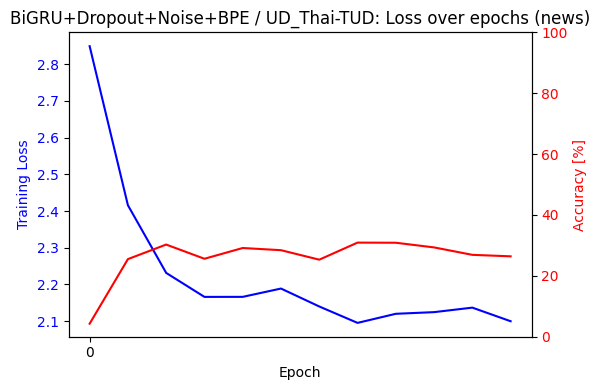

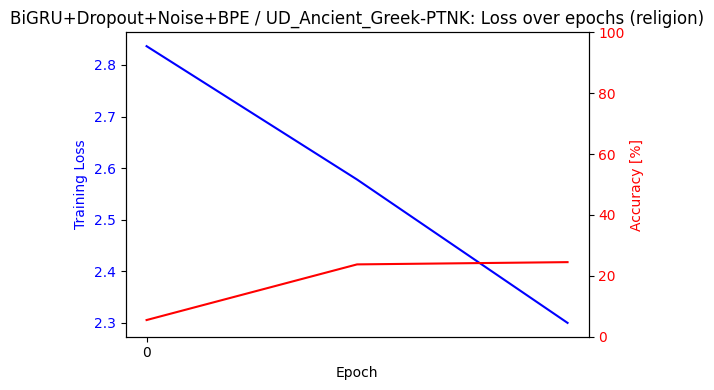

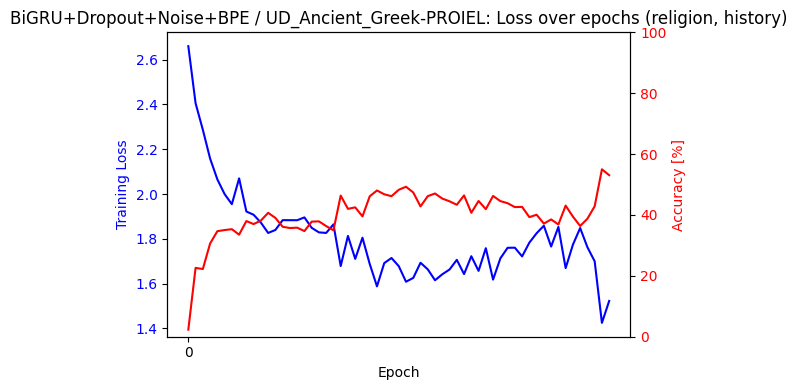

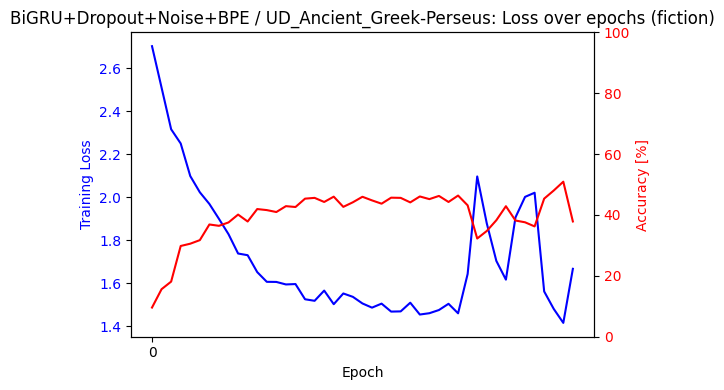

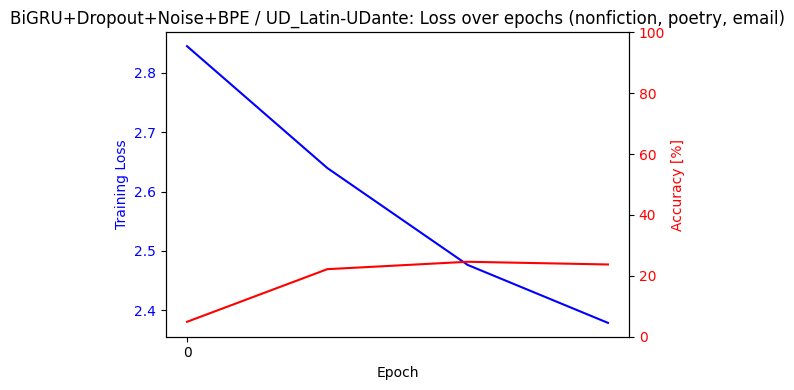

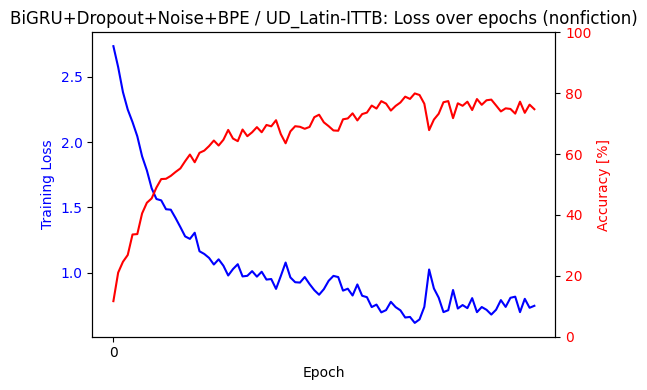

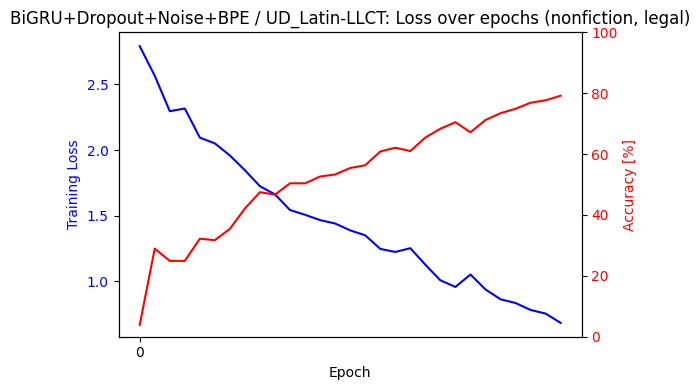

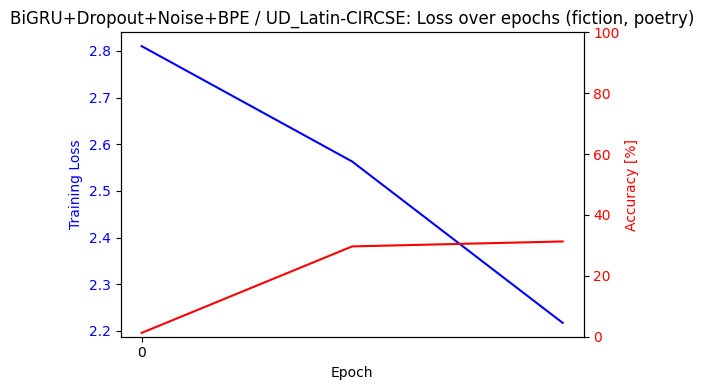

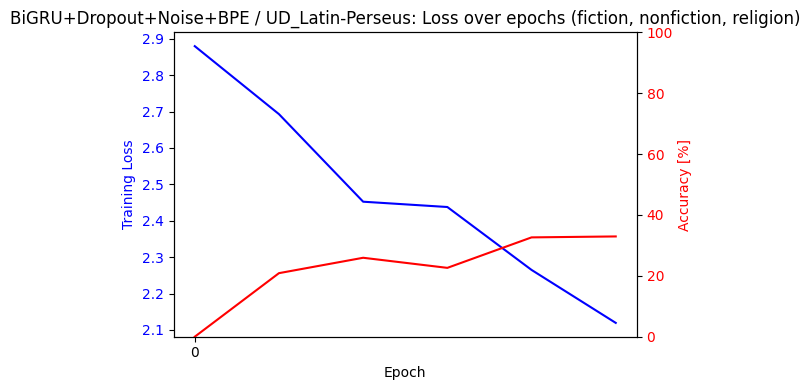

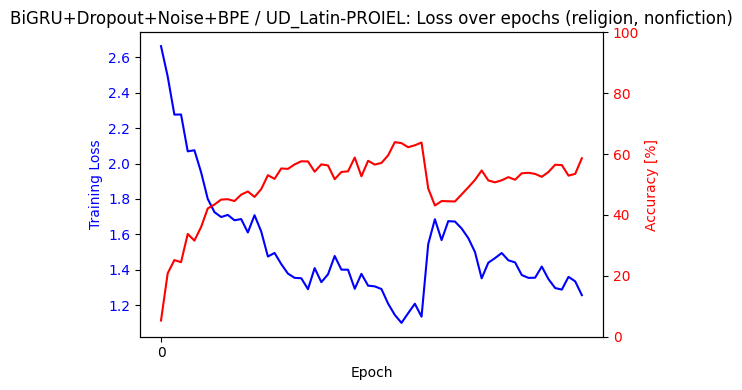

In [ ]:
for config_name in results:
    models, _, _ = results[config_name]
    dataset_names = list(models.keys())
    n = len(dataset_names)
    ncols = min(n, 3)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
    fig.suptitle(f"{config_name}", fontsize=16, fontweight='bold')
    axes = np.atleast_1d(axes).flatten()

    for i, name in enumerate(dataset_names):
        model, token2idx, tag2idx = models[name]
        repo = "https://github.com/UniversalDependencies/" + name + ".git"
        genres = ", ".join(repos[repo])

        ax1 = axes[i]
        ax1.set_title(f"{name}\n({genres})", fontsize=10)
        ax1.plot(model.training_loss_, 'b-')
        ax1.set_ylabel("Training Loss", color='b')
        ax1.set_xlabel("Epoch")
        ax1.tick_params(axis='y', labelcolor='b')

        ax2 = ax1.twinx()
        ax2.plot(model.training_accuracy_, 'r-')
        ax2.set_ylabel("Accuracy [%]", color='r')
        ax2.tick_params(axis='y', labelcolor='r')
        a = list(ax2.axis())
        a[2] = 0
        a[3] = 100
        ax2.axis(a)

        X_train = all_Xs_and_ys[name][0]
        t = np.arange(0, len(model.training_accuracy_), len(X_train)//batch_size+1)
        ax2.set_xticks(ticks=t)
        ax2.set_xticklabels(labels=np.arange(len(t)))

    # hide unused subplot axes
    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    fig.tight_layout()
    plt.show()

## Test data accuracy

Kommentar: jag behövde lägga till "X" till taggarna, eftersom det är en tagg som förekommer i vissa test-set utan att förekomma i respektive träningsset.

Jag använder konstant förutsägelse av den i train vanligaste POS-tag som baseline för respektive UD-set. 

Vanilla
	 UD_Thai-TUD
	Test accuracy 45.1%
	Baseline accuracy 30.0%
	 UD_Ancient_Greek-PTNK
	Test accuracy 37.3%
	Baseline accuracy 15.0%
	 UD_Ancient_Greek-PROIEL
	Test accuracy 59.8%
	Baseline accuracy 18.7%
	 UD_Ancient_Greek-Perseus
	Test accuracy 48.8%
	Baseline accuracy 21.7%
	 UD_Latin-UDante
	Test accuracy 24.9%
	Baseline accuracy 14.9%
	 UD_Latin-ITTB
	Test accuracy 83.5%
	Baseline accuracy 18.2%
	 UD_Latin-LLCT
	Test accuracy 71.4%
	Baseline accuracy 20.5%
	 UD_Latin-CIRCSE
	Test accuracy 30.2%
	Baseline accuracy 30.0%
	 UD_Latin-Perseus
	Test accuracy 33.9%
	Baseline accuracy 21.0%
	 UD_Latin-PROIEL
	Test accuracy 60.7%
	Baseline accuracy 19.9%
Vanilla+XPOS
	 UD_Thai-TUD
	Test accuracy 40.2%
	 UD_Ancient_Greek-PTNK
	Test accuracy 36.1%
	 UD_Ancient_Greek-PROIEL
	Test accuracy 64.0%
	 UD_Ancient_Greek-Perseus
	Test accuracy 26.8%
	 UD_Latin-UDante
	Test accuracy 17.4%
	 UD_Latin-ITTB
	Test accuracy 57.6%
	 UD_Latin-LLCT
	Test accuracy 33.0%
	 UD_Latin-CIRCSE
	Test accuracy 14

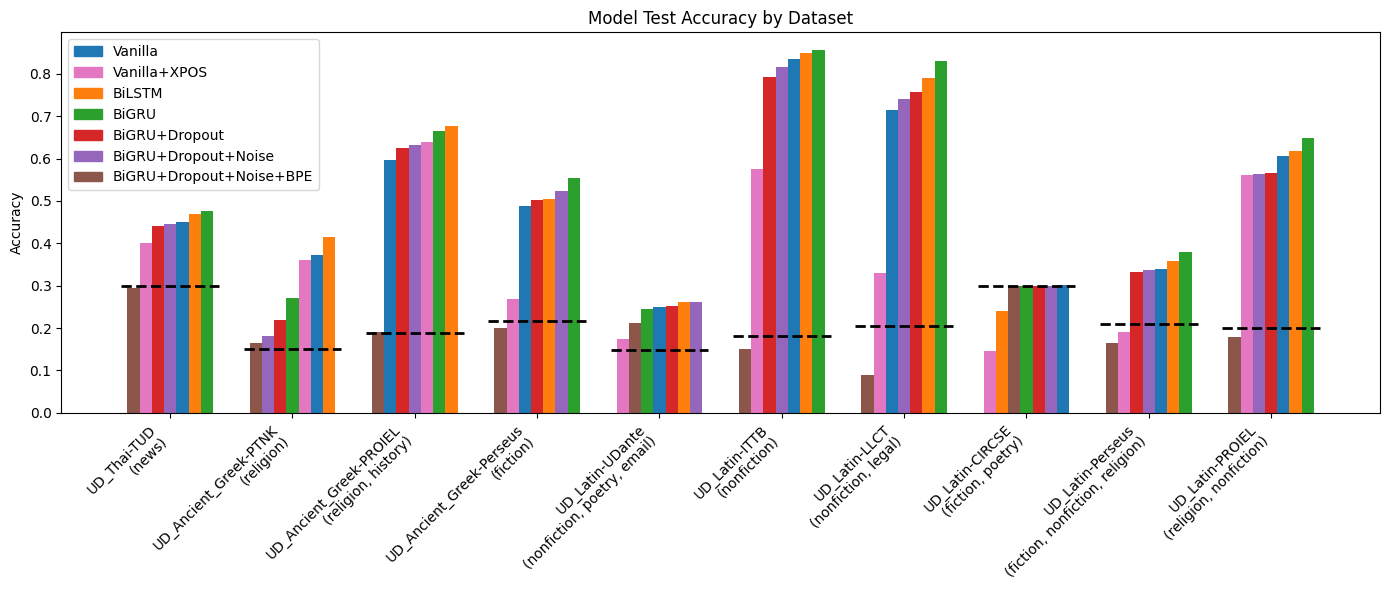

In [74]:
def inference(X, y, model, token2idx, tag2idx):
    with torch.no_grad():
        n_correct = 0
        n_total = 0

        dataset = UDDataset(X, y)
        dataloader = dataloader_loader(dataset, token2idx, tag2idx)

        for inputs, targets in dataloader:
            scores = model(inputs)
            predictions = scores.argmax(dim=2, keepdim=True).squeeze()
            mask = targets!=tag2idx['<PAD>']
            n_correct += (predictions[mask] == targets[mask]).sum().item()
            n_total += mask.sum().item()

    print("\tTest accuracy %.1f%%" % (100*n_correct/n_total))
    return n_correct, n_total

from collections import Counter

def majority_baseline(y_train, X_test, y_test, token2idx, tag2idx):
    '''
    Konstant förutsägelse för att ha en baseline.
    '''
    tags = [t for sent in y_train for t in sent if t != '<PAD>']
    majority_tag, _ = Counter(tags).most_common(1)[0]
    majority_idx = tag2idx[majority_tag]

    n_correct = 0
    n_total = 0

    dataset = UDDataset(X_test, y_test)
    dataloader = dataloader_loader(dataset, token2idx, tag2idx)

    for inputs, targets in dataloader:

        mask = targets != tag2idx['<PAD>']

        predictions = torch.full_like(targets, majority_idx)

        n_correct += (predictions[mask] == targets[mask]).sum().item()
        n_total += mask.sum().item()

    return n_correct, n_total


test_model_family_dict = {}
baseline_dict = {}

for model_family in results:
    print(model_family)

    models, _, _ = results[model_family]

    family_results = {}

    for name in models:
        print("\t", name)
        # Use XPOS data for XPOS models, UPOS data otherwise
        if "XPOS" in model_family:
            X_train, y_train, X_test, y_test = all_Xs_and_ys_xpos[name]
        else:
            X_train, y_train, X_test, y_test = all_Xs_and_ys[name]
        model, token2idx, tag2idx = models[name]

        # riktig model
        n_correct, n_total = inference(X_test, y_test, model, token2idx, tag2idx)
        family_results[name] = n_correct / n_total

        # baseline (only compute once per dataset)
        if name not in baseline_dict:
            base_correct, base_total = majority_baseline(y_train, X_test, y_test, token2idx, tag2idx)

            baseline_dict[name] = base_correct / base_total
            print("\tBaseline accuracy %.1f%%" % (100 * baseline_dict[name]))

    test_model_family_dict[model_family] = family_results


# ---------------- PLOT ----------------

import matplotlib.pyplot as plt
import numpy as np

families = list(test_model_family_dict.keys())
dataset_names = list(baseline_dict.keys())

n_families = len(families)
width = 0.10
group_width = n_families * width
gap = 0.3
x = np.arange(len(dataset_names)) * (group_width + gap)

family_colors = {
    "Vanilla": "tab:blue",
    "Vanilla+XPOS": "tab:pink",
    "BiLSTM": "tab:orange",
    "BiGRU": "tab:green",
    "BiGRU+Dropout": "tab:red",
    "BiGRU+Dropout+Noise": "tab:purple",
    "BiGRU+Dropout+Noise+BPE": "tab:brown"
}

fig = plt.figure(figsize=(14, 6))
ax = plt.subplot()

for di, dataset in enumerate(dataset_names):
    # gather (family, accuracy) pairs for this dataset, then sort by accuracy
    pairs = []
    for family in families:
        acc = test_model_family_dict[family][dataset]
        pairs.append((family, acc))
    pairs.sort(key=lambda p: p[1])

    for slot, (family, acc) in enumerate(pairs):
        offset = x[di] + (slot - (n_families - 1) / 2) * width
        ax.bar(
            offset,
            acc,
            width=width,
            color=family_colors[family],
        )

# baseline lines per dataset
for i, dataset in enumerate(dataset_names):
    baseline = baseline_dict[dataset]
    ax.hlines(
        baseline,
        x[i] - group_width / 2 - width / 2,
        x[i] + group_width / 2 + width / 2,
        colors="black",
        linestyles="dashed",
        linewidth=2
    )

# x labels with genres
x_labels = []
for name in dataset_names:
    repo = "https://github.com/UniversalDependencies/" + name + ".git"
    genres = ", ".join(repos[repo])
    x_labels.append(f"{name}\n({genres})")

ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45, ha="right")
ax.set_ylabel("Accuracy")
ax.set_title("Model Test Accuracy by Dataset")

# deduplicated legend
handles = [plt.Rectangle((0, 0), 1, 1, color=family_colors[f]) for f in families]
ax.legend(handles, families)

plt.tight_layout()
plt.show()

## Separat experiment 1: Genre

Hur klarar sig en modell tränad på en genre i andra genrer på samma språk? Vi kör några experiment.

repos = {
    "https://github.com/UniversalDependencies/UD_Thai-TUD.git": ["news"],
    "https://github.com/UniversalDependencies/UD_Ancient_Greek-PTNK.git": ["religion"],
    "https://github.com/UniversalDependencies/UD_Ancient_Greek-PROIEL.git": ["religion", "history"],
    "https://github.com/UniversalDependencies/UD_Ancient_Greek-Perseus.git": ["fiction"],
    "https://github.com/UniversalDependencies/UD_Latin-UDante.git": ["nonfiction", "poetry", "email"],
    "https://github.com/UniversalDependencies/UD_Latin-ITTB.git": ["nonfiction"],
    "https://github.com/UniversalDependencies/UD_Latin-LLCT.git": ["nonfiction", "legal"],
    "https://github.com/UniversalDependencies/UD_Latin-CIRCSE.git": ["fiction", "poetry"],
    "https://github.com/UniversalDependencies/UD_Latin-Perseus.git": ["fiction", "nonfiction", "religion"],
    "https://github.com/UniversalDependencies/UD_Latin-PROIEL.git": ["religion", "nonfiction"],
}

## Separat experiment 2: Bigger is better? Boosta den sämsta modellen med ren djup-maxxing

In [80]:
bigger_results = initialize_singularity(verbose=False, epochs=5, layers=10)

TypeError: RNNBase.__init__() got an unexpected keyword argument 'layers'